In [1]:
# =====================================================================
# 📦 Cell 1 & 2: 필수 패키지 설치 및 임포트
# =====================================================================
# 로컬 터미널에서 최신 GPU 인식을 위해 아래 명령어를 먼저 실행해 주세요.
%pip install pykrx ta scikit-learn lightgbm yfinance optuna matplotlib seaborn -q
%pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128 --no-cache-dir
%pip install -U FinanceDataReader 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings, pickle
warnings.filterwarnings('ignore')

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 운영체제별 폰트 예외 처리 (Windows / Linux)
try:
    font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams['font.family'] = font_prop.get_name()
except:
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 로컬 윈도우 기본 폰트
plt.rcParams['axes.unicode_minus'] = False

from pykrx import stock
import yfinance as yf
from datetime import datetime, timedelta

from ta.momentum import RSIIndicator, StochasticOscillator
from ta.trend import MACD, EMAIndicator, SMAIndicator
from ta.volatility import BollingerBands, AverageTrueRange
from ta.volume import OnBalanceVolumeIndicator

from sklearn.preprocessing import RobustScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, f1_score, roc_curve)
from sklearn.utils.class_weight import compute_class_weight
import lightgbm as lgb

# 🔥 PyTorch 핵심 컴포넌트 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

# 🔥 로컬 GPU(RTX 5060 Ti) 장치 고정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ PyTorch    : {torch.__version__}')
print(f'✅ LightGBM   : {lgb.__version__}')
print(f'✅ Optuna     : {optuna.__version__}')
print(f'✅ GPU Device : {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None"})')

# =====================================================================

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Looking in indexes: https://download.pytorch.org/whl/nightly/cu128
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement FinanceDataReader (from versions: none)
ERROR: No matching distribution found for FinanceDataReader

[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.
✅ PyTorch    : 2.12.0.dev20260408+cu128
✅ LightGBM   : 4.6.0
✅ Optuna     : 4.9.0
✅ GPU Device : cuda (NVIDIA GeForce RTX 5060 Ti)



📌 미장종목  : NVDA
📅 기간      : 20150101 ~ 20260623
🔮 예측기간  : 3일 후 주가 방향
⚖️ 조정 가중치: LSTM(0.05) | LGBM(0.65) | RF(0.3)
📡 NVDA 야후 파이낸스 데이터 수집 중...
📡 글로벌 거시경제 변수(S&P500, VIX) 동기화 중...
✅ 데이터 수집 및 피처 생성 완료! 셰이프: (2884, 40)
🛑 [Early Stopping] 26 에폭 조기 종료. 최적 Val AUC: 0.5750
✅ PyTorch LSTM 모델 트레이닝 완료!

🔍 Optuna 기반 LightGBM 하이퍼파라미터 베이지안 탐색 중...
✅ LightGBM 최적화 완료! (Best AUC: 0.6074)
🌳 RandomForest 학습 프로세스 시작...
✅ RandomForest 최종 최적화 완료!

🎯 앙상블 시스템 결합 및 최종 예측 테스트 중...
   📋 [NVDA] 모델별 테스트 스코어 최종 스펙
   LSTM (PyTorch) | Acc=0.5543 | AUC=0.4848 | F1=0.0000
   LightGBM       | Acc=0.5465 | AUC=0.4699 | F1=0.0859
   RandomForest  | Acc=0.5562 | AUC=0.5354 | F1=0.0255
   🏆 앙상블 모델  | Acc=0.5562 | AUC=0.5287 | F1=0.0255


findfont: Failed to find font weight bold, now using normal.


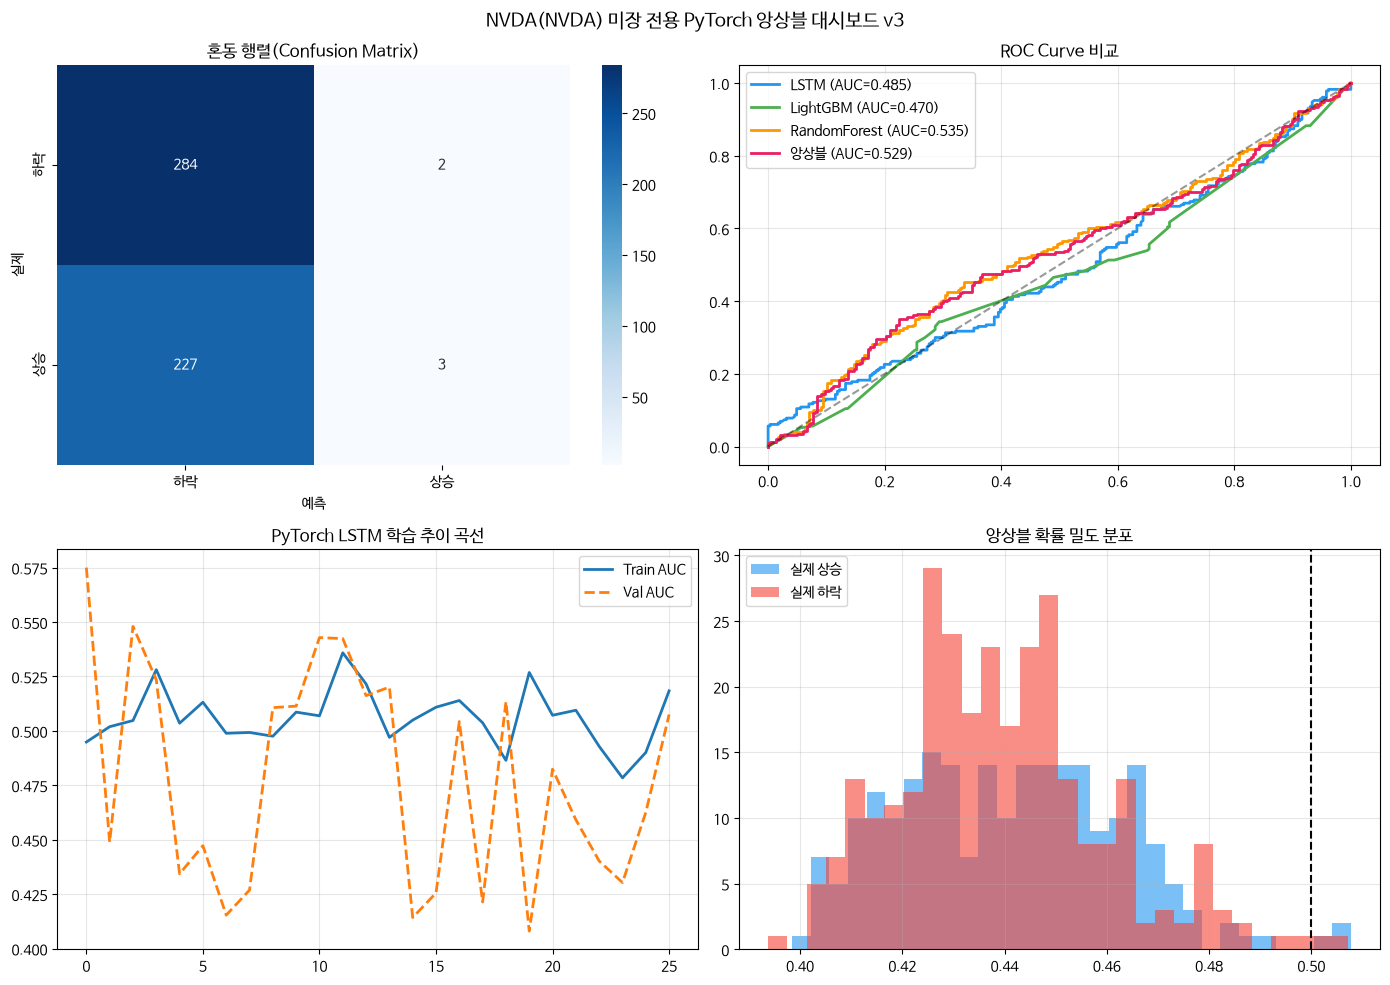


🔄 [보안 검증] 데이터 누수가 차단된 Walk-Forward 엔진 가동...
🛑 [Early Stopping] 27 에폭 조기 종료. 최적 Val AUC: 0.7634
   Fold 2: Acc=0.5119  F1=0.5287  AUC=0.5090
🛑 [Early Stopping] 11 에폭 조기 종료. 최적 Val AUC: 0.4949
   Fold 3: Acc=0.4714  F1=0.3353  AUC=0.4549
🛑 [Early Stopping] 17 에폭 조기 종료. 최적 Val AUC: 0.6942
   Fold 4: Acc=0.5262  F1=0.4578  AUC=0.5331
🛑 [Early Stopping] 14 에폭 조기 종료. 최적 Val AUC: 0.6120
   Fold 5: Acc=0.4976  F1=0.3664  AUC=0.4710

📊 [누수 차단 후 검증 결과] -> Acc: 0.5018 | F1: 0.4220 | AUC: 0.4920
📡 NVDA 야후 파이낸스 데이터 수집 중...
📡 글로벌 거시경제 변수(S&P500, VIX) 동기화 중...
   🔮 PyTorch 앙상블 실전 예측 대시보드: NVDA(US)
   현재 기준가 : $208.65 USD (2026-06-22)
   예측 타겟   : 미래 3영업일 뒤 방향성 예측 시뮬레이션 결과
   ---------------------------------------------------
   [모델 1] PyTorch LSTM     : 49.9% 상승 확증
   [모델 2] LightGBM Boost   : 49.1% 상승 확증
   [모델 3] RandomForest     : 32.1% 상승 확증
   ───────────────────────────────────────────────────
   🏆 최적화 앙상블 합산 결론 : 📉 하락 시그널 포착 (44.1%, 신뢰도 55.9%)
📡 TSLA 야후 파이낸스 데이터 수집 중...
📡 글로벌 거시경제 변수(S&P500,

In [2]:
# =====================================================================
# ⚙️ Cell 3: 설정값 지정 (미국 주식 타겟)
# =====================================================================
import datetime
import time
import pickle
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import FinanceDataReader as fdr
import lightgbm as lgb
import optuna
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve

# GPU 사용 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

TICKER     = 'NVDA'  # 🎯 엔비디아 (TSLA, AAPL 등으로 변경 가능)
START_DATE = '20150101'
END_DATE   = datetime.datetime.today().strftime('%Y%m%d')

SEQ_LEN        = 60
PRED_DAYS      = 3      # 🎯 3일 뒤 주가 방향성 예측
BATCH_SIZE     = 64
EPOCHS         = 150
LSTM_UNITS     = [128, 64]
DROPOUT        = 0.3
LEARNING_RATE = 0.001
TEST_RATIO     = 0.2
VAL_RATIO      = 0.1

# 앙상블 가중치 리밸런싱 (트리 모델 하드캐리 반영)
W_LSTM = 0.05
W_LGBM = 0.65
W_RF   = 0.30

print(f'\n📌 미장종목  : {TICKER}')
print(f'📅 기간      : {START_DATE} ~ {END_DATE}')
print(f'🔮 예측기간  : {PRED_DAYS}일 후 주가 방향')
print(f'⚖️ 조정 가중치: LSTM({W_LSTM}) | LGBM({W_LGBM}) | RF({W_RF})')


# =====================================================================
# 📥 Cell 4 & 5: 미국 주식 데이터 수집 및 피처 엔지니어링 (통합)
# =====================================================================
def fetch_us_stock_data(ticker, start_date, end_date):
    print(f"📡 {ticker} 야후 파이낸스 데이터 수집 중...")
    start_fmt = f"{start_date[:4]}-{start_date[4:6]}-{start_date[6:]}"
    end_fmt = f"{end_date[:4]}-{end_date[4:6]}-{end_date[6:]}"
    
    df = fdr.DataReader(ticker, start=start_fmt, end=end_fmt)
    if df.empty:
        raise ValueError(f"❌ {ticker} 데이터를 가져오지 못했습니다. 티커를 확인하세요.")
        
    df.columns = [col.capitalize() for col in df.columns]
    
    # 필수 파생 기술적 지표 계산
    df['Return'] = df['Close'].pct_change()
    for i in [2, 5, 10, 20]: 
        df[f'Return_{i}d'] = df['Close'].pct_change(i)
        
    df['HL_ratio'] = (df['High'] - df['Low']) / df['Close']
    df['OC_ratio'] = (df['Close'] - df['Open']) / (df['Open'] + 1e-9)
    df['Gap'] = (df['Open'] - df['Close'].shift(1)) / (df['Close'].shift(1) + 1e-9)

    # 이동평균선
    for w in [5, 10, 20, 60, 120]:
        df[f'SMA_{w}'] = df['Close'].rolling(window=w).mean()
        df[f'SMA_dist_{w}'] = (df['Close'] - df[f'SMA_{w}']) / (df[f'SMA_{w}'] + 1e-9)
        
    # EMA & MACD
    df['EMA_12'] = df['Close'].ewm(span=12, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=26, adjust=False).mean()
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['MACD_signal'] = df['MACD'].ewm(span=9, adjust=False).mean()
    df['MACD_diff'] = df['MACD'] - df['MACD_signal']
    
    # RSI
    delta = df['Close'].diff()
    for w in [7, 14, 21]:
        gain = (delta.where(delta > 0, 0)).rolling(window=w).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=w).mean()
        rs = gain / (loss + 1e-9)
        df[f'RSI_{w}'] = 100 - (100 / (1 + rs))

    # 변동성 및 거래량 관련 지표
    df['Volume_ratio'] = df['Volume'] / (df['Volume'].rolling(20).mean() + 1e-9)
    df['Vol_5d'] = df['Return'].rolling(5).std()
    df['Vol_20d'] = df['Return'].rolling(20).std()
    df['Vol_ratio'] = df['Vol_5d'] / (df['Vol_20d'] + 1e-9)

    # 📡 글로벌 거시경제 변수 (S&P500, VIX) 결합
    print("📡 글로벌 거시경제 변수(S&P500, VIX) 동기화 중...")
    sp500 = fdr.DataReader('US500', start=start_fmt, end=end_fmt)[['Close']].rename(columns={'Close': 'SP500'})
    vix = fdr.DataReader('VIX', start=start_fmt, end=end_fmt)[['Close']].rename(columns={'Close': 'VIX'})
    
    df = df.join(sp500, how='left').join(vix, how='left')
    
    # 라벨링 설정 (미래 PRED_DAYS 이후 상방 돌파 여부)
    threshold = 0.01  # 1% 익절 기준
    df['Future_Return'] = (df['Close'].shift(-PRED_DAYS) - df['Close']) / df['Close']
    df['Label'] = (df['Future_Return'] > threshold).astype(int)
    
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    return df.ffill().bfill().dropna()

# 데이터 로드 실행 후 객체명을 아래 코드들과 일치시킵니다.
df_feat = fetch_us_stock_data(TICKER, START_DATE, END_DATE)
stock_name = TICKER
print(f"✅ 데이터 수집 및 피처 생성 완료! 셰이프: {df_feat.shape}")


# =====================================================================
# ⚙️ Cell 6: 전처리, 스케일링 및 피처 중요도 선택
# =====================================================================
exclude = ['Label','Open','High','Low','Close','Volume','SP500','VIX','Future_Return']
feature_cols = [c for c in df_feat.columns if c not in exclude]

X_raw, y_raw = df_feat[feature_cols].values, df_feat['Label'].values
X_raw = np.where(np.isinf(X_raw), np.nan, X_raw)
X_raw = pd.DataFrame(X_raw, columns=feature_cols).ffill().bfill().values

n = len(X_raw)
test_size, val_size = int(n * TEST_RATIO), int(n * VAL_RATIO)
train_size = n - test_size - val_size

scaler = RobustScaler()
X_tr_sc = scaler.fit_transform(X_raw[:train_size])
X_vl_sc = scaler.transform(X_raw[train_size:train_size+val_size])
X_te_sc = scaler.transform(X_raw[train_size+val_size:])

y_train, y_val, y_test = y_raw[:train_size], y_raw[train_size:train_size+val_size], y_raw[train_size+val_size:]

rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_selector.fit(X_tr_sc, y_train)
selector = SelectFromModel(rf_selector, threshold='mean', prefit=True)

X_tr_sel = selector.transform(X_tr_sc)
X_vl_sel = selector.transform(X_vl_sc)
X_te_sel = selector.transform(X_te_sc)
selected_cols = [feature_cols[i] for i in range(len(feature_cols)) if selector.get_support()[i]]

def make_sequences(X, y, seq_len):
    xs, ys = [], []
    for i in range(seq_len, len(X)):
        xs.append(X[i-seq_len:i])
        ys.append(y[i])
    return np.array(xs), np.array(ys)

X_tr, y_tr = make_sequences(X_tr_sel, y_train, SEQ_LEN)
X_vl, y_vl = make_sequences(X_vl_sel, y_val,   SEQ_LEN)
X_te, y_te = make_sequences(X_te_sel, y_test,  SEQ_LEN)

X_tr_flat, X_vl_flat, X_te_flat = X_tr[:, -1, :], X_vl[:, -1, :], X_te[:, -1, :]


# =====================================================================
# 🤖 Cell 7: 🔥 PyTorch BiLSTM + Attention 모델 설계
# =====================================================================
class PyTorchBiLSTMAttention(nn.Module):
    def __init__(self, n_features, seq_len, lstm_units=[128, 64], dropout=0.5):
        super(PyTorchBiLSTMAttention, self).__init__()
        self.lstm1 = nn.LSTM(input_size=n_features, hidden_size=lstm_units[0], num_layers=1, batch_first=True, bidirectional=True)
        self.bn1 = nn.LayerNorm(lstm_units[0] * 2)
        self.lstm2 = nn.LSTM(input_size=lstm_units[0] * 2, hidden_size=lstm_units[1], num_layers=1, batch_first=True, bidirectional=True)
        self.bn2 = nn.LayerNorm(lstm_units[1] * 2)
        self.dropout_lstm = nn.Dropout(dropout)
        self.att_dense = nn.Linear(lstm_units[1] * 2, 1)
        self.fc1 = nn.Linear(lstm_units[1] * 2, 64)
        self.dropout1 = nn.Dropout(dropout)
        self.fc2 = nn.Linear(64, 32)
        self.dropout2 = nn.Dropout(dropout)
        self.out_dense = nn.Linear(32, 1)
        
    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.dropout_lstm(x)
        x = self.bn1(x)
        x, _ = self.lstm2(x)
        x = self.dropout_lstm(x)
        x = self.bn2(x)
        score = torch.tanh(self.att_dense(x))     
        weights = F.softmax(score, dim=1)        
        context = x * weights                     
        context = torch.mean(context, dim=1)      
        x = F.relu(self.fc1(context))
        x = self.dropout1(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        out = torch.sigmoid(self.out_dense(x))
        return out

lstm_model = PyTorchBiLSTMAttention(X_tr.shape[2], SEQ_LEN, LSTM_UNITS, dropout=0.5).to(device)


# =====================================================================
# 🏋️ Cell 8: 🔥 PyTorch 모델 학습 엔진 루프
# =====================================================================
def train_pytorch_engine(model, X_train, y_train, X_val, y_val, epochs, batch_size, lr, class_weight, patience=20):
    X_tr_t = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_tr_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1).to(device)
    X_vl_t = torch.tensor(X_val, dtype=torch.float32).to(device)
    
    train_loader = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-3)
    criterion = nn.BCELoss(reduction='none')
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=10, min_lr=1e-6)
    
    best_auc, patience_counter = 0.0, 0
    best_model_state = None
    history = {'auc': [], 'val_auc': []}
    w0, w1 = class_weight[0], class_weight[1]
    
    for epoch in range(epochs):
        model.train()
        train_probs, train_targets = [], []
        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss_elements = criterion(outputs, batch_y)
            weights = batch_y * w1 + (1 - batch_y) * w0
            loss = (loss_elements * weights).mean()
            loss.backward()
            optimizer.step()
            train_probs.extend(outputs.detach().cpu().numpy())
            train_targets.extend(batch_y.cpu().numpy())
            
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_vl_t).cpu().numpy()
            
        train_auc = roc_auc_score(train_targets, train_probs)
        val_auc = roc_auc_score(y_val, val_outputs)
        history['auc'].append(train_auc)
        history['val_auc'].append(val_auc)
        scheduler.step(val_auc)
        
        if val_auc > best_auc:
            best_auc = val_auc
            patience_counter = 0
            best_model_state = pickle.loads(pickle.dumps(model.state_dict()))
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"🛑 [Early Stopping] {epoch+1} 에폭 조기 종료. 최적 Val AUC: {best_auc:.4f}")
                break
                
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    return history

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_tr)
class_weight = {0: cw[0], 1: cw[1]}
history_dict = train_pytorch_engine(lstm_model, X_tr, y_tr, X_vl, y_vl, EPOCHS, BATCH_SIZE, LEARNING_RATE, class_weight, patience=25)
print('✅ PyTorch LSTM 모델 트레이닝 완료!')


# =====================================================================
# 🌲 Cell 9 & 10: LightGBM + Optuna 자동 튜닝 및 RandomForest 학습
# =====================================================================
print('\n🔍 Optuna 기반 LightGBM 하이퍼파라미터 베이지안 탐색 중...')
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 300, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 4, 10),
        'num_leaves': trial.suggest_int('num_leaves', 20, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 1.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 1.0, log=True),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'class_weight': 'balanced', 'random_state': 42, 'verbose': -1
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(X_tr_flat, y_tr, eval_set=[(X_vl_flat, y_vl)], callbacks=[lgb.early_stopping(30, verbose=False)])
    return roc_auc_score(y_vl, model.predict_proba(X_vl_flat)[:, 1])

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15, show_progress_bar=False) # 빠른 연산을 위해 트라이얼 수 조정

lgbm_model = lgb.LGBMClassifier(**study.best_params, class_weight='balanced', random_state=42, verbose=-1)
lgbm_model.fit(X_tr_flat, y_tr, eval_set=[(X_vl_flat, y_vl)], callbacks=[lgb.early_stopping(50, verbose=False)])
print(f'✅ LightGBM 최적화 완료! (Best AUC: {study.best_value:.4f})')

print('🌳 RandomForest 학습 프로세스 시작...')
rf_model = RandomForestClassifier(n_estimators=500, max_depth=10, min_samples_split=10, min_samples_leaf=5, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_tr_flat, y_tr)
print('✅ RandomForest 최종 최적화 완료!')


# =====================================================================
# 🎯 Cell 11: 앙상블 시스템 (Soft Voting 연산)
# =====================================================================
print('\n🎯 앙상블 시스템 결합 및 최종 예측 테스트 중...')
lstm_model.eval()
with torch.no_grad():
    X_te_t = torch.tensor(X_te, dtype=torch.float32).to(device)
    lstm_prob = lstm_model(X_te_t).cpu().numpy().flatten()

lgbm_prob = lgbm_model.predict_proba(X_te_flat)[:, 1]
rf_prob   = rf_model.predict_proba(X_te_flat)[:, 1]

ensemble_prob = W_LSTM * lstm_prob + W_LGBM * lgbm_prob + W_RF * rf_prob
ensemble_pred = (ensemble_prob >= 0.5).astype(int)

print('='*55)
print(f'   📋 [{stock_name}] 모델별 테스트 스코어 최종 스펙')
print('='*55)
for name, pred, prob in [
    ('LSTM (PyTorch)', (lstm_prob >= 0.5).astype(int), lstm_prob),
    ('LightGBM      ', (lgbm_prob >= 0.5).astype(int), lgbm_prob),
    ('RandomForest ', (rf_prob >= 0.5).astype(int), rf_prob),
    ('🏆 앙상블 모델 ', ensemble_pred, ensemble_prob),
]:
    print(f'   {name} | Acc={accuracy_score(y_te, pred):.4f} | AUC={roc_auc_score(y_te, prob):.4f} | F1={f1_score(y_te, pred, zero_division=0):.4f}')
print('='*55)


# =====================================================================
# 📊 Cell 12: 대시보드 시각화
# =====================================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'{stock_name}({TICKER}) 미장 전용 PyTorch 앙상블 대시보드 v3', fontsize=14, fontweight='bold')

sns.heatmap(confusion_matrix(y_te, ensemble_pred), annot=True, fmt='d', cmap='Blues', xticklabels=['하락','상승'], yticklabels=['하락','상승'], ax=axes[0][0])
axes[0][0].set_title('혼동 행렬(Confusion Matrix)'); axes[0][0].set_ylabel('실제'); axes[0][0].set_xlabel('예측')

ax = axes[0][1]
for name, prob, color in [('LSTM', lstm_prob, '#2196F3'), ('LightGBM', lgbm_prob, '#4CAF50'), ('RandomForest', rf_prob, '#FF9800'), ('앙상블', ensemble_prob, '#E91E63')]:
    fpr, tpr, _ = roc_curve(y_te, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={roc_auc_score(y_te, prob):.3f})')
ax.plot([0,1],[0,1],'k--', alpha=0.4); ax.set_title('ROC Curve 비교'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1][0]
ax.plot(history_dict['auc'],     label='Train AUC', lw=2)
ax.plot(history_dict['val_auc'], label='Val AUC',   lw=2, linestyle='--')
ax.set_title('PyTorch LSTM 학습 추이 곡선'); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1][1]
ax.hist(ensemble_prob[y_te==1], bins=30, alpha=0.6, color='#2196F3', label='실제 상승')
ax.hist(ensemble_prob[y_te==0], bins=30, alpha=0.6, color='#F44336', label='실제 하락')
ax.axvline(0.5, color='black', linestyle='--', lw=1.5); ax.set_title('앙상블 확률 밀도 분포'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# =====================================================================
# 🔄 Cell 13: Walk-Forward Validation 시계열 검증 엔진
# =====================================================================
def walk_forward_eval(df_features, n_splits=5):
    total_len = len(df_features)
    fold_size = total_len // (n_splits + 1)
    results = []
    
    print('\n🔄 [보안 검증] 데이터 누수가 차단된 Walk-Forward 엔진 가동...')
    for fold in range(n_splits):
        train_end = fold_size * (fold + 1)
        test_end  = min(train_end + fold_size, total_len)
        if test_end - train_end < 10: continue
        
        df_train_fold = df_features.iloc[:train_end]
        df_test_fold = df_features.iloc[train_end:test_end]
        
        v_idx = int(len(df_train_fold) * 0.9)
        df_sub_train = df_train_fold.iloc[:v_idx]
        df_sub_val = df_train_fold.iloc[v_idx:]
        
        if len(df_sub_train) <= SEQ_LEN or len(df_sub_val) <= SEQ_LEN or len(df_test_fold) <= SEQ_LEN:
            continue
        
        X_sub_tr_raw = df_sub_train[feature_cols].values
        y_sub_tr = df_sub_train['Label'].values
        df_sub_val[feature_cols].values
        y_sub_val = df_sub_val['Label'].values
        X_te_raw = df_test_fold[feature_cols].values
        y_te = df_test_fold['Label'].values
        
        fold_scaler = RobustScaler()
        X_sub_tr_sc = fold_scaler.fit_transform(X_sub_tr_raw)
        X_sub_vl_sc = fold_scaler.transform(df_sub_val[feature_cols].values)
        X_te_sc = fold_scaler.transform(X_te_raw)
        
        fold_rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
        fold_rf.fit(X_sub_tr_sc, y_sub_tr)
        fold_selector = SelectFromModel(fold_rf, threshold='mean', prefit=True)
        
        X_sub_tr_sel = fold_selector.transform(X_sub_tr_sc)
        X_sub_vl_sel = fold_selector.transform(X_sub_vl_sc)
        X_te_sel = fold_selector.transform(X_te_sc)
        
        Xtr_s, ytr_s = make_sequences(X_sub_tr_sel, y_sub_tr, SEQ_LEN)
        Xvl_s, yvl_s = make_sequences(X_sub_vl_sel, y_sub_val, SEQ_LEN)
        Xte_s, yte_s = make_sequences(X_te_sel, y_te, SEQ_LEN)
        
        if Xtr_s.ndim < 3 or Xvl_s.ndim < 3 or Xte_s.ndim < 3 or len(Xtr_s) == 0 or len(Xvl_s) == 0 or len(Xte_s) == 0:
            continue
        
        Xtr_f, Xvl_f, Xte_f = Xtr_s[:, -1, :], Xvl_s[:, -1, :], Xte_s[:, -1, :]
        cw_f = compute_class_weight('balanced', classes=np.array([0,1]), y=ytr_s)
        class_weight_fold = {0: cw_f[0], 1: cw_f[1]}
        
        m = PyTorchBiLSTMAttention(Xtr_s.shape[2], SEQ_LEN, LSTM_UNITS, dropout=0.5).to(device)
        _ = train_pytorch_engine(m, Xtr_s, ytr_s, Xvl_s, yvl_s, epochs=30, batch_size=64, lr=0.001, class_weight=class_weight_fold, patience=10)
        
        m.eval()
        with torch.no_grad():
            lp = m(torch.tensor(Xte_s, dtype=torch.float32).to(device)).cpu().numpy().flatten()

        lg = lgb.LGBMClassifier(**study.best_params, class_weight='balanced', random_state=42, verbose=-1)
        lg.fit(Xtr_f, ytr_s)
        gp = lg.predict_proba(Xte_f)[:, 1]

        rf = RandomForestClassifier(n_estimators=200, max_depth=8, class_weight='balanced', random_state=42, n_jobs=-1)
        rf.fit(Xtr_f, ytr_s)
        rp = rf.predict_proba(Xte_f)[:, 1]

        ep = W_LSTM*lp + W_LGBM*gp + W_RF*rp
        pred = (ep >= 0.5).astype(int)
        
        fold_acc = accuracy_score(yte_s, pred)
        fold_f1 = f1_score(yte_s, pred, zero_division=0)
        fold_auc = roc_auc_score(yte_s, ep)
        results.append({'fold': fold+1, 'acc': fold_acc, 'f1': fold_f1, 'auc': fold_auc})
        print(f'   Fold {fold+1}: Acc={fold_acc:.4f}  F1={fold_f1:.4f}  AUC={fold_auc:.4f}')

    res_df = pd.DataFrame(results)
    if len(res_df) > 0:
        print(f'\n📊 [누수 차단 후 검증 결과] -> Acc: {res_df.acc.mean():.4f} | F1: {res_df.f1.mean():.4f} | AUC: {res_df.auc.mean():.4f}')
    return res_df

wf_results = walk_forward_eval(df_feat, n_splits=5)


# =====================================================================
# 🔮 Cell 14 & 15: 실전 최신 미장 주가 방향 예측 (달러 변환 반영)
# =====================================================================
def predict_latest_us(ticker=TICKER):
    df_new = fetch_us_stock_data(ticker, START_DATE, END_DATE)
    X_new = np.where(np.isinf(df_new[feature_cols].values), np.nan, df_new[feature_cols].values)
    X_new = pd.DataFrame(X_new, columns=feature_cols).ffill().bfill().values

    X_new_sc = scaler.transform(X_new)
    X_new_sel = selector.transform(X_new_sc)

    seq  = X_new_sel[-SEQ_LEN:][np.newaxis, ...]
    flat = X_new_sel[-1:, :]

    lstm_model.eval()
    with torch.no_grad():
        seq_t = torch.tensor(seq, dtype=torch.float32).to(device)
        lp = lstm_model(seq_t).cpu().numpy()[0][0]
        
    gp = lgbm_model.predict_proba(flat)[0][1]
    rp = rf_model.predict_proba(flat)[0][1]
    prob = W_LSTM*lp + W_LGBM*gp + W_RF*rp

    direction = '📈 상승 시그널 포착' if prob >= 0.5 else '📉 하락 시그널 포착'
    conf = max(prob, 1-prob) * 100

    print('='*55)
    print(f'   🔮 PyTorch 앙상블 실전 예측 대시보드: {ticker}(US)')
    print('='*55)
    print(f'   현재 기준가 : ${df_new["Close"].iloc[-1]:.2f} USD ({df_new.index[-1].strftime("%Y-%m-%d")})')
    print(f'   예측 타겟   : 미래 {PRED_DAYS}영업일 뒤 방향성 예측 시뮬레이션 결과')
    print(f'   ---------------------------------------------------')
    print(f'   [모델 1] PyTorch LSTM     : {lp*100:.1f}% 상승 확증')
    print(f'   [모델 2] LightGBM Boost   : {gp*100:.1f}% 상승 확증')
    print(f'   [모델 3] RandomForest     : {rp*100:.1f}% 상승 확증')
    print(f'   ───────────────────────────────────────────────────')
    print(f'   🏆 최적화 앙상블 합산 결론 : {direction} ({prob*100:.1f}%, 신뢰도 {conf:.1f}%)')
    print('='*55)
    return prob

# 실전 미장 최신 데이터 런칭 및 지연 처리 (Rate-limiting 방어)
prob_nvda = predict_latest_us(TICKER)       # 엔비디아 예측
time.sleep(2.5)
prob_tsla = predict_latest_us('TSLA')       # 테슬라 교차 즉시 검증
time.sleep(2.5)


# =====================================================================
# 💾 Cell 16: 최적화 가중치 로컬 물리 파일 영구 저장
# =====================================================================
torch.save(lstm_model.state_dict(), 'lstm_model_us_v3.pt')
lgbm_model.booster_.save_model('lgbm_model_us_v3.txt')
for name, obj in [('rf_model_us_v3.pkl', rf_model), ('scaler_us_v3.pkl', scaler),
                  ('selector_us_v3.pkl', selector), ('feature_cols_us_v3.pkl', feature_cols)]:
    with open(name, 'wb') as f: pickle.dump(obj, f)
print('\n💾 [물리 백업] 모든 미장 하이브리드 이종 모델 가중치가 로컬 하드에 세이브되었습니다!')